In [1]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import colors

from scipy.integrate import quad #znana funkcija
from scipy.integrate import cumulative_trapezoid  # numerični podatki

np.set_printoptions(legacy='1.25')

In [2]:
def graf(v=5, s=5):
    '''
        Funkcija pripravi graf in nastavi koordinatne osi 
    '''
    fig, ax = plt.subplots(figsize=(s,v))
    ax.set_prop_cycle(color=colors.Texas)
    ax.set_xlabel('x', loc='right')
    ax.set_ylabel('y', loc='top')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False);
    ax.axis('equal') 
    return ax

#np.set_printoptions(legacy='1.25')
#import warnings
#warnings.filterwarnings("ignore")

# Integral - numerične metode

Pri računanju določenih integralov se pogosto srečamo s funkcijami, ki jih ne moremo analitično integrirati, torej ne znamo izračunati nedoločenega integrala ali pa je to zelo zapleteno. V teh primerih uporabimo numerične metode s katerimi izračunamo dovolj natančen približek. V primerih, ko znamo analitično izračunati nedoločen integral, bomo raje uporabili analitični pristop in določen integral izračunali iz nedoločenega. Več o računanju nedoločenih integralov najdete v poglavju o uporabi knjižnice za simbolno računanje SymPy.

Za numerično računanje integralov v Pythonu uporabljamo več funkcij iz knjižnic __NumPy__ in __SciPy__. Če poznamo funkcijski predpis integranda, v Pythonu za računanje določenega integrala običajno uporabimo funkcijo `quad()` iz knjižnice __SciPy__, ki uporablja adaptivne metode računanja in je zelo natančna. Če pa ne poznamo niti integranda, torej funkcije, ki jo želimo integrirati, za računanje integrala lahko uporabimo  trapezno ali Simpsonovo metodo. Funkcije, ki implementirata ti metodi, potrebujeta le vzorec funkcijskih vrednostih integranda. Posledično lahko torej računamo tudi integrale neznanih funkcij. To je uporabno, kadar imamo na voljo podatke iz meritev ali simulacij.  

V nadaljevanju so predstavljene trije pristopi računanja določenega integrala z uporabo numeričnih metod.

## Integral znane funkcije

Kadar poznamo funkcijski predpis in ne znamo analitično izračunati integrala, običajno uporabimo funkcijo `quad()` iz knjižnice scipy.integrate. 

##### Primer:
Izračunaj določen integral
$$\int_{0}^{1} sin(x^2) dx$$

Integrand moramo najprej definirati kot Python funkcijo.

In [3]:
def f(x):
    return np.sin(x**2)

Oglejmo si graf funkcije $f$ na intervalu $[-3, 3]$.

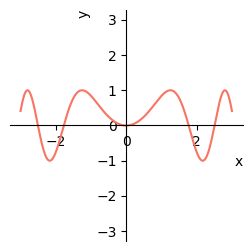

In [4]:
ax = graf(3,3)
x = np.linspace(-3, 3, 1000)
ax.plot(x, f(x));

Za izračun vrednosti integrala uporabimo scipy `quad()` funkcijo. Le-tej moramo podati vsaj tri argumente, in sicer prvi argument je integrand, drugi je spodnja in tretji je zgornja meja.

In [5]:
I = quad(f, 0, 1)
integral, napaka = I

I

(0.3102683017233811, 3.444670123846428e-15)

Rezultat je par števil, pri čemer je prvo število vrednost integrala in drugo je ocenjena vrednost napake. Spomnimo, da z numerično metodo vedno izračunamo le približek. Zato funkcija vrne tudi oceno napake. 

V nadaljevanju si poglejmo še nekaj posebnosti.

## Oscilatorni integral

Pri integriranju oscilatornih funkcij lahko pride do težav, če je konvergenca zelo počasna. Naslednji primer to nazorno pokaže. Funkcija `quad()` ne zna pravilno oceniti doprinosa repa funkcije in z običajnim pristopom dobimo napačen rezultat.

##### Primer:
Izračunaj integral 
$$\int_0^{\infty}\frac{\sin{x}}{x}dx$$

Pravilen rezultat znaša $\frac{\pi}{2}$. Sedaj pa poglejmo, kaj izračuna `quad`.


In [6]:
def f(x):
    return np.sin(x)/x

Funkcija oscilira in amplituda se zelo počasi znižuje. 

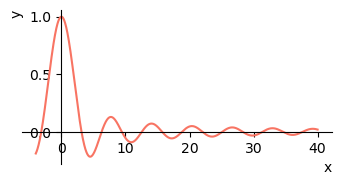

In [7]:
ax = graf(2,4)
x = np.linspace(-4, 40, 1000)
ax.axis('auto')
ax.plot(x, f(x));

In [8]:
I = quad(f, 0, np.inf)
integral, napaka = I
integral, napaka

C:\Users\Nenad\AppData\Local\Temp\ipykernel_45880\3649155317.py:1: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I = quad(f, 0, np.inf)


(2.2478679634689205, 3.2903230524472633)

V rezultatih vidimo, da je ocenjena napaka zelo velika! Prav tako vidimo, da je izračunana vrednost resnično zelo odstopa od prave vrednosti in je dejanska napaka precej velika: 

In [9]:
integral - np.pi/2

0.6770716366740239

Za oscilatorne funkcije oblike 

$$f(x)=g(x)*sin(w\cdot x)$$

ima funkcija `quad` poseben način računanja. Definirati moramo funkcijo $g(x)$, nato pa funkciji `quad` kot utež podati ime funkcije zaradi katere $f(x)$ oscilira.

Sedaj nastopi še težava, da kot integrand podajamo funkcijo $\frac{1}{x}$, ki ima v točki 0 singularnost. Zato bomo spodnjo mejo za malenkost premaknili.

In [10]:
def g(x):
    return 1/x

I = quad(g, 1e-10, np.inf, weight='sin', wvar=1) # vrednost wvar določimo iz sin(wvar * x)

I

(1.5707963266770455, 3.82564227057368e-09)

Rezultat je sedaj dosti natančnejši:

In [11]:
I[0]-np.pi/2

-1.1785106224238007e-10

## Integral z divergenco na meji

Nekateri integrali so konvergentni, čeprav imajo singularnost na meji. Funkcija `quad()` se uspešno spopade s težavo. Poglejmo naslednji primer.

##### Primer:
Izrčaunaj integral
$$\int_0^{1}\frac{e^x}{\sqrt{x}}dx$$

In [12]:
def f(x):
    return np.exp(-x)/np.sqrt(x)

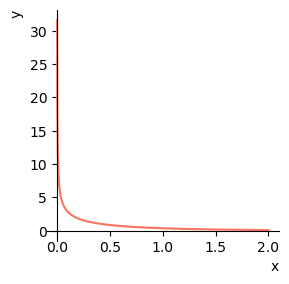

In [19]:
ax = graf(3,3)
ax.axis('auto')
x = np.linspace(1e-3, 2, 1000)  #risanje ne moremo začeti v 0 zaradi sigularnosti
ax.plot(x, f(x));

In [18]:
I = quad(f, 0, 1)
I

(1.4936482656248504, 4.0730441241976223e-10)

Omenjeni integral konvergira tudi, če zgornjo mejo postavimo v neskončnost in ima tako dve "težavi".

In [20]:
I = quad(f, 0, np.inf)
I

(1.7724538509051053, 9.585621185692617e-11)

## Integriranje funkcij s parametri

Do sedaj smo integrand definirali kot funkcijo $y = f(x)$. Pri tem je $x$ neodvisna spremenljivka funkcije $f$. V praksi s funkcijo opišemo obnašanje nekega sistema. Sedaj si zamislimo, da opazujemo sistem, ki deluje kot dušeni oscilator. V praksi je to lahko most, ki zaniha zaradi prometne obremenitve, lahko je stavba, ki jo strese potres, ali tla v stavbi, ki jih strese uporaba večjega stroja. V vseh primerih nas bo zanimalo, kako se sistem odzove pri določeni frekvenci nihanja. 
Sistem lahko opišemo s funkcijo, ki ima ob spremenljivki $x$, ki predstavlja čas opazovanja sistema, še dve dodatni spremenljivki, ki določata zunanje parametre, ki vplivajo na sistem. 

$$f(x) = \frac{\sin{bx}}{x}e^{-ax}$$

Pri tem je $a$ dušenje nihanja in $b$ frekvenca vzbujanja sistema.

Sedaj pa navedeno funkcijo integrirajmo po $x$, pri tem nas zanima, kako se integral spreminja, če se spreminjajo parametri, ki določajo značilnosti sistema. To nam pove, kako močno sistem zaniha.

Z uporabo funkcije `quad()` lahko za vsako kombinacijo $a$ in $b$ izračunamo vrednost integrala na definiranem območju. Če določimo $a$ in $b$, dobimo primer, ki smo ga opisali že zgoraj. Vendar pa `quad()` omogoča tudi  integriranje funkcije $f(x, a, b)$, čeprav je sedaj $f$ funkcija treh spremenljivk. 

Kot običajno bomo najprej definirali funkcijo, ki predstavlja integrand. Pri tem je pomembno, v kakšnem vrstnem redu zapišemo parametre. Najprej moramo navesti spremenljivko po kateri bomo integrirali. V našem primeru je to $x$, ostali dve pa sta za vsak izračun integrala konstanti.

In [21]:
def f(x, a, b):
    return (np.sin(b*x)/x)*np.exp(-a*x)

Pri integriranju moramo vrednosti obeh konstant numerično določiti:

In [22]:
I1 = quad(f, 0, np.inf, args=(1, 20))
I2 = quad(f, 0, np.inf, args=(20, 20))
I1, I2

((1.5208379308514444, 1.4919634397313436e-08),
 (0.7853981633973632, 1.1880089413954242e-08))

Sedaj lahko izračunamo integral za katerokoli kombinacijo $a$ in $b$, torej
$$I(a,b) =\int{\frac{\sin{bx}}{x}e^{-ax}dx}$$

Pripravimo vektorja vrednosti za $a$ in $b$. 

In [23]:
sez_a = np.arange(1, 10)
sez_b = np.arange(1, 10)

In izračunamo integrale za vse kombinacije $a$ in $b$.

In [ ]:
I_ab = [[a, b, quad(f, 0, np.inf, args=(a,b))[0]] for a in sez_a for b in sez_b]
I_ab

## Redke funkcije

Nekatere funkcije imajo vrednosti različne od nič le na redkih in kratkih območjih neodvisne spremenljivke. Integriranje takšnih funkcij s `quad()` zahteva določene prilagoditve, sicer bo rezultat napačen.

##### Primer:
Izračunaj integral 
$$\int_{\infty}^{\infty}{e^{-(x-300)^2}+e^{-(x+300)^2}dx}$$

In [25]:
def f(x):
    return np.exp(-(x-300)**2)+np.exp(-(x+300)**2)

Graf funkcije nam pokaže, da ima funkcija dva impulza, enega pri $x=-300$ in drugega pri $x=300$.

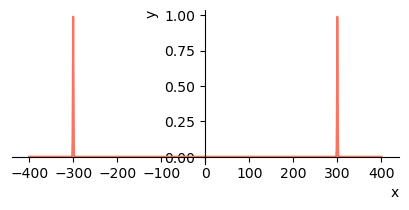

In [26]:
ax = graf(2,5)
ax.axis('auto')
x = np.linspace(-400, 400, 1000)
ax.plot(x, f(x));

Poglejmo en impuz bolj od blizu:

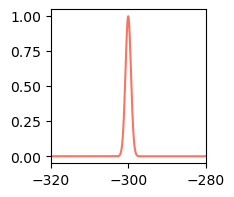

In [27]:
fig, ax = plt.subplots(figsize=(2,2))
ax.set_prop_cycle(color=colors.Texas)
ax.set_xlim(-320, -280)
x = np.linspace(-320, -280, 1000)
ax.plot(x, f(x));

Poskusimo izračunati integral z uporabo `quad()` na običajen način.

In [28]:
quad(f, -np.inf, np.inf)

(0.0, 0.0)

Rezultat je očitno napačen, saj smo se grafično prepričali, da površina pod krivuljo ni enaka 0.

V takšnih primerih moramo funkciji `quad()` nekoliko pomagati z namigom, kje naj poišče vrednosti. S parametrom `points` funkciji podamo točke, kjer pričakujemo vrednosti različne od 0. Zapomnimo pa si, da v tem primeru meje integrala ne morejo biti v neskončnosti.

In [29]:
quad(f, -800, 800, points=[-300, 300])

(3.5449077018110344, 7.76944675879792e-09)

## Integriranje neznane funkcije 

Nekatere pojave lahko izmerimo, vendar ne poznamo funkcijskega predpisa, ki opisuje merjeni pojav. Za ilustracijo poglejmo preprost primer spremljanja stroškov projekta. Vsak dan lahko zabeležimo, koliko stroškov je nastalo na projektu ta dan. V daljšem obdobju pa nas zanima, kako izgleda krivulja kumulativne porabe skozi čas.  

Rezultat opisanega primera je integral funkcije dnevne porabe. Vendar pa seveda običajno takšne funkcije ne poznamo.

Če imamo na voljo numerične vrednosti funkcije, lahko vseeno izračunamo potek integrirane funkcije. V ta namen bomo uporabili SciPy funkcijo `cumulative_trapezoid()`. 

Ker dejanskih podatkov nimamo, bomo najprej ustvarili namišljene podatke o dnevni porabi.

In [96]:
poraba = (-np.arange(-500, 500, 10)**2)
poraba = poraba - min(poraba)
poraba = poraba - 40000 * (np.random.rand(100))

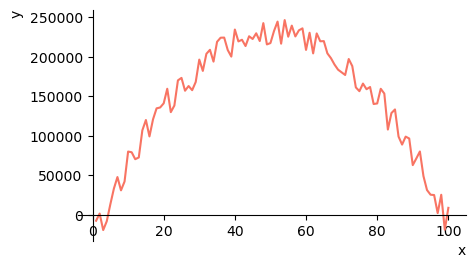

In [97]:
ax = graf(3,5)
ax.axis('auto')
dnevi = range(1,101) 
ax.plot(dnevi, poraba);

Kumulativna poraba do določenega dne je integral zgornje funkcije od 0 do izbranega dne.

In [98]:
integral = cumulative_trapezoid(poraba, dnevi, initial=0)
integral

array([ 0.00000000e+00, -3.07164237e+03, -1.20359752e+04, -2.58807958e+04,
       -2.34766885e+04, -4.21341657e+02,  3.99476222e+04,  7.92396263e+04,
        1.15706706e+05,  1.76729404e+05,  2.56282747e+05,  3.30998971e+05,
        4.02412018e+05,  4.92093806e+05,  6.05499339e+05,  7.15054532e+05,
        8.25021392e+05,  9.52762546e+05,  1.08801808e+06,  1.22644716e+06,
        1.37673728e+06,  1.52146155e+06,  1.65555093e+06,  1.80976169e+06,
        1.98147889e+06,  2.14662696e+06,  2.30663071e+06,  2.46698488e+06,
        2.62990726e+06,  2.81219625e+06,  3.00148951e+06,  3.19443137e+06,
        3.40073291e+06,  3.60210463e+06,  3.80855677e+06,  4.03014814e+06,
        4.25439883e+06,  4.47086236e+06,  4.67529157e+06,  4.89268581e+06,
        5.11968918e+06,  5.34022529e+06,  5.55783446e+06,  5.77764405e+06,
        6.00191932e+06,  6.22808645e+06,  6.45296184e+06,  6.68428539e+06,
        6.91346820e+06,  7.12999562e+06,  7.35498252e+06,  7.59357281e+06,
        7.82417960e+06,  

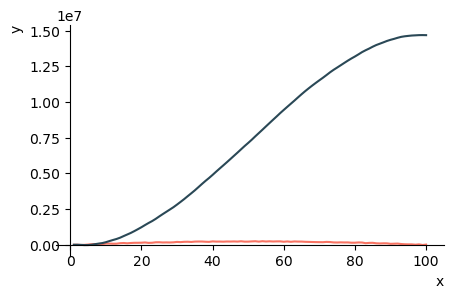

In [99]:
ax = graf(3, 5)
ax.axis('auto')
ax.plot(dnevi, poraba, label='poraba')
ax.plot(dnevi, integral, label='kumulativno');